In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data = pd.read_csv('/content/drive/MyDrive/WB/train_wb.csv')

In [5]:
data[data['route_id'] == 12]

,Unnamed: 0,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
3286894,3286894,19,12,2025-03-01 00:00:00,78,520,43,379,510,1135,14496,3121,32.0
3286895,3286895,19,12,2025-03-01 00:30:00,44,495,0,415,385,0,0,0,35.0
3286896,3286896,19,12,2025-03-01 01:00:00,51,369,99,380,607,410,0,5444,40.0
3286897,3286897,19,12,2025-03-01 01:30:00,30,298,7,411,359,900,0,2104,47.0
3286898,3286898,19,12,2025-03-01 02:00:00,33,276,93,415,383,0,22815,2437,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291231,3291231,19,12,2025-05-30 08:30:00,66,385,62,205,159,172,0,5192,57.0
3291232,3291232,19,12,2025-05-30 09:00:00,57,436,152,203,265,230,0,1080,48.0
3291233,3291233,19,12,2025-05-30 09:30:00,71,609,74,375,243,252,0,1264,27.0
3291234,3291234,19,12,2025-05-30 10:00:00,103,589,82,596,192,62,5854,4306,35.0


In [4]:
data.sample(5)

,Unnamed: 0,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
2347594,2347594,41,412,2025-04-30 17:00:00,1604,24,1855,1320,1479,1494,0,0,17.0
848671,848671,33,501,2025-04-11 06:30:00,10,157,5,175,491,500,860,1483,82.0
302661,302661,41,516,2025-05-03 19:30:00,1501,48,1182,1774,2258,2506,0,0,20.0
1778661,1778661,33,895,2025-04-27 23:30:00,37,256,33,27,647,968,8017,1017,157.0
588837,588837,13,825,2025-04-25 13:30:00,5122,305,4673,3531,3918,4376,2268,74,71.0


In [5]:
data = data.drop(columns='Unnamed: 0')

In [6]:
data.isna().sum()

,0
office_from_id,0
route_id,0
timestamp,0
status_1,0
status_2,0
status_3,0
status_4,0
status_5,0
status_6,0
status_7,0


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
print(data['target_2h'].max())
print(data['target_2h'].min())

1517.0
0.0


In [9]:
(data['target_2h'] == 0).sum() / data.shape[0] # доля нулей в таргете

np.float64(0.048664440350069095)

In [10]:
data['office_from_id'].nunique()

53

In [11]:
data['route_id'].nunique()

1000

In [12]:
data.shape

(4342000, 12)

In [13]:
data['office_from_id'].value_counts()

,count
office_from_id,
13,277888
12,264862
10,247494
41,238810
1,234468
22,217100
33,212758
21,186706
25,147628


Видно, что на разных складах разный объем данных, норм ли это?

Проверяем данные на наличие разрывов во времени:

In [14]:
data[data['office_from_id'] == 1]['timestamp'].min()

'2025-03-01 00:00:00'

In [15]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

for office in data['office_from_id'].unique():
    dates = data.loc[data['office_from_id'] == office, 'timestamp']

    min_date = dates.min()
    max_date = dates.max()
    n_rows = len(dates)

    expected_rows = int((max_date - min_date).total_seconds() // (30 * 60)) + 1
    missing_rows = expected_rows - n_rows

    print(
        f"OFFICE: {office}, "
        f"MIN DATE: {min_date}, "
        f"MAX DATE: {max_date}, "
        f"N_ROWS: {n_rows}, "
        f"EXPECTED_ROWS: {expected_rows}, "
        f"MISSING_ROWS: {missing_rows}"
    )

OFFICE: 4, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 30394, EXPECTED_ROWS: 4342, MISSING_ROWS: -26052
OFFICE: 10, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 247494, EXPECTED_ROWS: 4342, MISSING_ROWS: -243152
OFFICE: 33, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 212758, EXPECTED_ROWS: 4342, MISSING_ROWS: -208416
OFFICE: 12, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 264862, EXPECTED_ROWS: 4342, MISSING_ROWS: -260520
OFFICE: 24, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 91182, EXPECTED_ROWS: 4342, MISSING_ROWS: -86840
OFFICE: 43, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 99866, EXPECTED_ROWS: 4342, MISSING_ROWS: -95524
OFFICE: 39, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_ROWS: 69472, EXPECTED_ROWS: 4342, MISSING_ROWS: -65130
OFFICE: 50, MIN DATE: 2025-03-01 00:00:00, MAX DATE: 2025-05-30 10:30:00, N_RO

Смотрим на примере конкретного склада и timestamp


In [16]:
data[(data['office_from_id'] == 4) & (data['timestamp'] == '2025-05-30 10:30:00')]

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
4341,4,29,2025-05-30 10:30:00,2008,290,1322,132,89,3,3240,277,126.0
416831,4,642,2025-05-30 10:30:00,149,254,115,147,82,0,200,0,70.0
1532725,4,930,2025-05-30 10:30:00,1763,389,1171,186,90,2,2712,232,51.0
2032055,4,949,2025-05-30 10:30:00,259,274,174,177,201,234,1258,0,77.0
2240471,4,830,2025-05-30 10:30:00,2021,314,1342,173,95,1,2987,273,60.0
2535727,4,193,2025-05-30 10:30:00,141,166,94,84,71,199,460,0,4.0
4211739,4,183,2025-05-30 10:30:00,154,200,115,142,97,176,326,0,3.0


Смотрим на количество timestampов для 4 склада

In [17]:
data[data['office_from_id'] == 4]['timestamp'].value_counts()

,count
timestamp,
2025-05-30 10:30:00,7
2025-03-01 00:00:00,7
2025-03-01 00:30:00,7
2025-03-01 01:00:00,7
2025-03-01 01:30:00,7
...,...
2025-03-01 05:00:00,7
2025-03-01 04:30:00,7
2025-03-01 04:00:00,7


Получается, что на одном складе сразу несколько направлений по разным маршрутам (переформулировать)
И временные промежутки для всех складов одинаковые и без пропусков по времени

In [18]:
data.groupby('office_from_id').agg(
    n_rows=('timestamp', 'size'),
    n_timestamps=('timestamp', 'nunique')
)

,n_rows,n_timestamps
office_from_id,,
1,234468,4342
2,78156,4342
3,117234,4342
4,30394,4342
5,17368,4342
6,43420,4342
7,56446,4342
8,30394,4342
9,8684,4342


Анализ таргета

In [19]:
data.groupby('office_from_id')['target_2h'].sum()

,target_2h
office_from_id,
1,27236672.0
2,2132909.0
3,5607813.0
4,1178178.0
5,1620437.0
6,3104827.0
7,1056737.0
8,3905461.0
9,936309.0


Анализ таргета от timestamp


In [20]:
data_an = data.copy()

In [21]:
format_string = "%Y-%m-%d %H:%M:%S"
st = '2025-05-01 10:30:00'
data_an['date_time'] = pd.to_datetime(data_an['timestamp'], format_string)
data_an['day_of_week'] = data_an['date_time'].dt.dayofweek

In [22]:
data_an.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,date_time,day_of_week
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0,2025-03-01 00:00:00,5
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0,2025-03-01 00:30:00,5
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0,2025-03-01 01:00:00,5
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0,2025-03-01 01:30:00,5
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0,2025-03-01 02:00:00,5


Text(0.5, 1.0, 'Sum of target_2h by day_of_week')

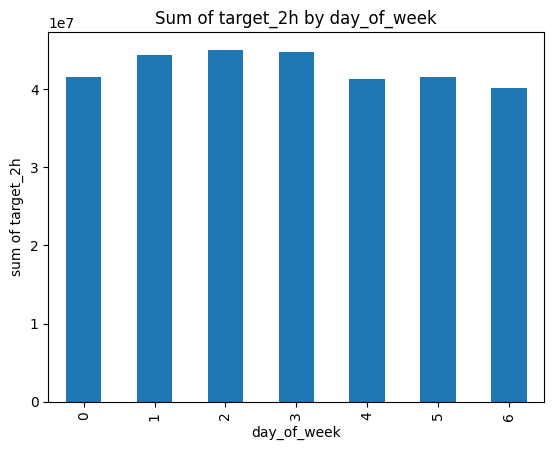

In [23]:
grouped_data_sum = data_an.groupby('day_of_week')['target_2h'].sum()
grouped_data_median = data_an.groupby('day_of_week')['target_2h'].median()
grouped_data_mean = data_an.groupby('day_of_week')['target_2h'].mean()
zero_share_by_day = (data_an['target_2h'] == 0).groupby(data_an['day_of_week']).mean()
grouped_data_sum.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('sum of target_2h')
plt.title('Sum of target_2h by day_of_week')

Text(0.5, 1.0, 'Median of target_2h by day_of_week')

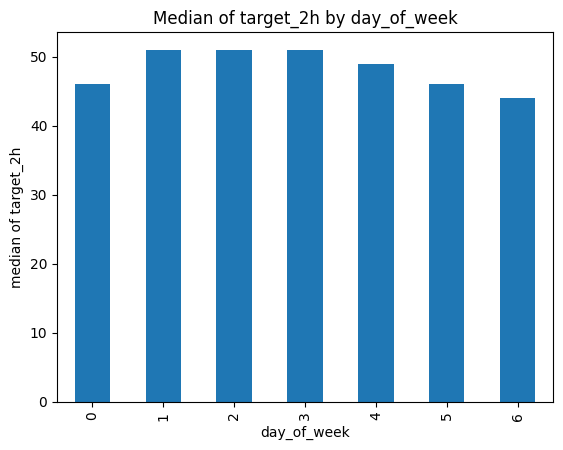

In [24]:

grouped_data_median.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('median of target_2h')
plt.title('Median of target_2h by day_of_week')

Text(0.5, 1.0, 'Mean of target_2h by day_of_week')

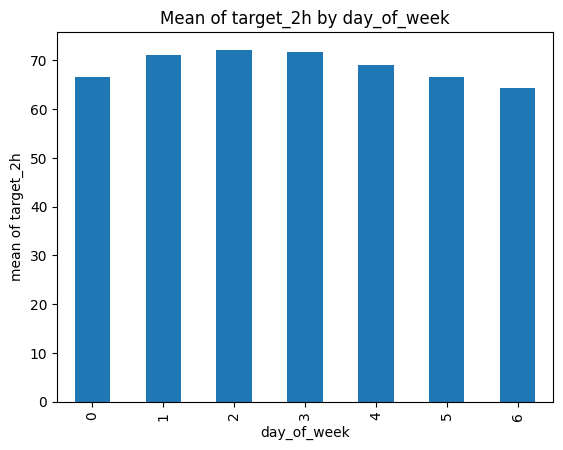

In [25]:

grouped_data_mean.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('mean of target_2h')
plt.title('Mean of target_2h by day_of_week')

Text(0.5, 1.0, 'Share of zero target_2h by day_of_week')

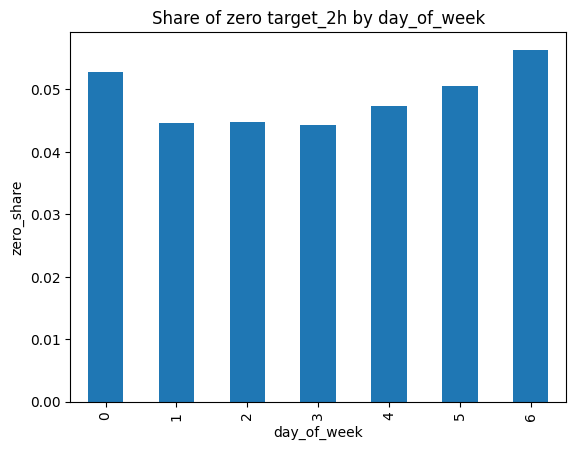

In [26]:
zero_share_by_day.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('zero_share')
plt.title('Share of zero target_2h by day_of_week')

- дни 1-3 выглядят самыми активными
- дни 5-6 самыми слабыми
- день 0 тоже слабее середины недели
- и по mean, и по median, и по zero_share картина согласованная
по этим графикам видно, что простое деление "выходной/не выходной" может быть слишком грубым

In [27]:
data_an['hour'] = data_an['timestamp'].dt.hour
data_an['minute'] = data_an['timestamp'].dt.minute
data_an['time_slot'] = data_an['hour'] * 2 + (data_an['minute'] // 30)

In [28]:
slot_stats = data_an.groupby('time_slot').agg(
    target_sum=('target_2h', 'sum'),
    target_mean=('target_2h', 'mean'),
    target_median=('target_2h', 'median')
)

slot_stats['zero_share'] = (data_an['target_2h'] == 0).groupby(data_an['time_slot']).mean()

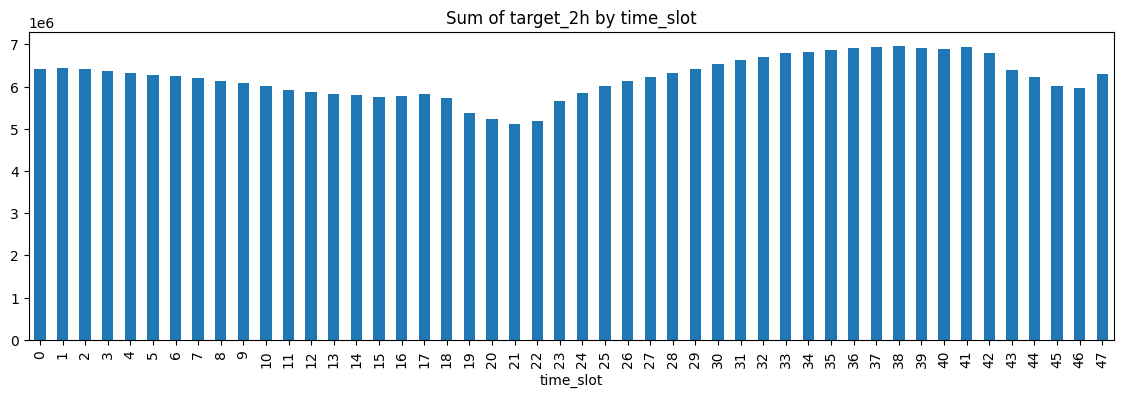

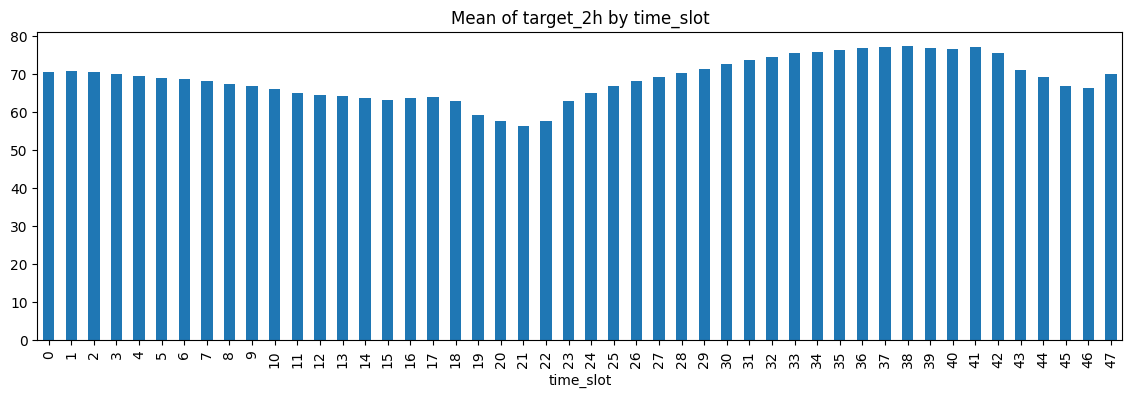

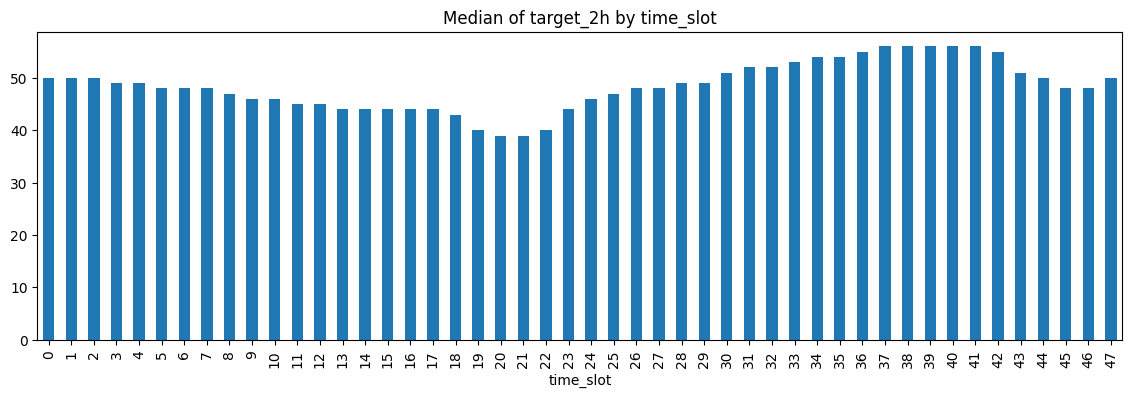

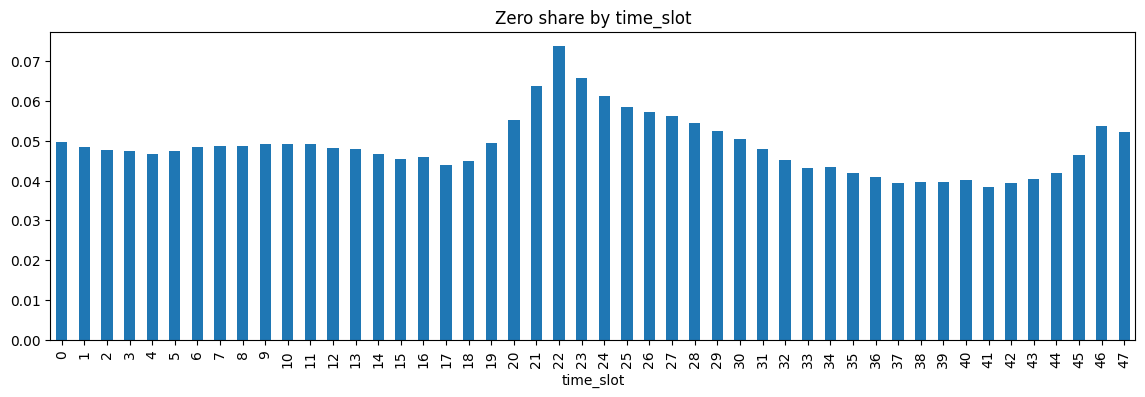

In [29]:
slot_stats['target_sum'].plot(kind='bar', figsize=(14, 4), title='Sum of target_2h by time_slot')
plt.show()

slot_stats['target_mean'].plot(kind='bar', figsize=(14, 4), title='Mean of target_2h by time_slot')
plt.show()

slot_stats['target_median'].plot(kind='bar', figsize=(14, 4), title='Median of target_2h by time_slot')
plt.show()

slot_stats['zero_share'].plot(kind='bar', figsize=(14, 4), title='Zero share by time_slot')
plt.show()

Просадка примерно в районе слотов 20–22

То есть примерно 10:00–11:00:

mean падает;
median падает;
zero_share резко растет.

Это значит, что в этот период:

типичный объем ниже;
нулей больше;
это не только эффект выбросов, а реальное изменение поведения.
3. Самые сильные значения — ближе к слотам 37–41

То есть примерно 18:30–20:30:

mean максимален;
median максимальна;
zero_share минимален.

То есть в вечерние часы:

отгрузки чаще;
типичный объем выше;
пустых наблюдений меньше.
4. Ночь/раннее утро не выглядят “мертвыми”

Это интересный момент.
По графикам начало суток не проваливается катастрофически. Значит, бинарный признак day/night может оказаться слишком грубым: внутри суток картина не “день хорошо, ночь плохо”, а более сложная.

Главный вывод

Признак time_slot точно полезен.
И он, похоже, информативнее, чем просто бинарный day / not day.

ВЫВОД: ДОБАВЛЯЕМ time_slot, day_of_week в data

In [30]:
format_string = "%Y-%m-%d %H:%M:%S"
data['timestamp'] = pd.to_datetime(data_an['timestamp'], format_string)
data['day_of_week'] = data['timestamp'].dt.dayofweek

In [31]:
data['hour'] = data['timestamp'].dt.hour
data['minute'] = data['timestamp'].dt.minute
data['time_slot'] = data['hour'] * 2 + (data['minute'] // 30)
data = data.drop(columns=['hour', 'minute'])

In [32]:
data.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day_of_week,time_slot
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0,5,0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0,5,1
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0,5,2
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0,5,3
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0,5,4


Анализ таргета уже не только по времени, но и по складам/маршрутам

Text(0.5, 1.0, 'Mean of target_2h by storage')

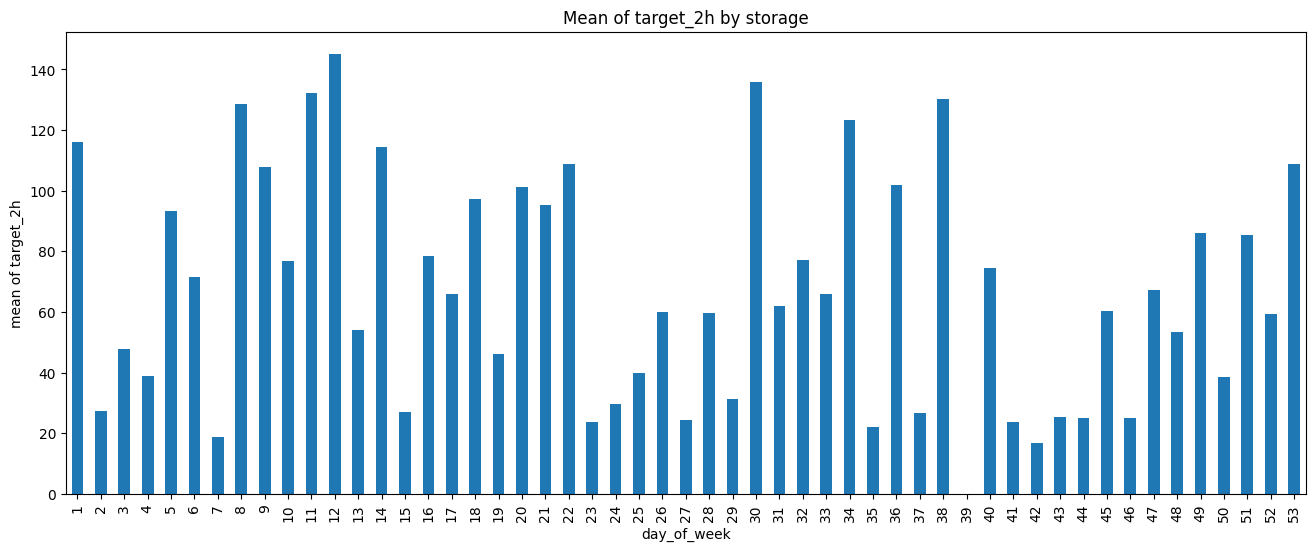

In [33]:
plt.figure(figsize=(16, 6))
grouped_data_mean_sklad = data.groupby('office_from_id')['target_2h'].mean()
grouped_data_mean_sklad.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('mean of target_2h')
plt.title('Mean of target_2h by storage')

Text(0.5, 1.0, 'Sum of target_2h by storage')

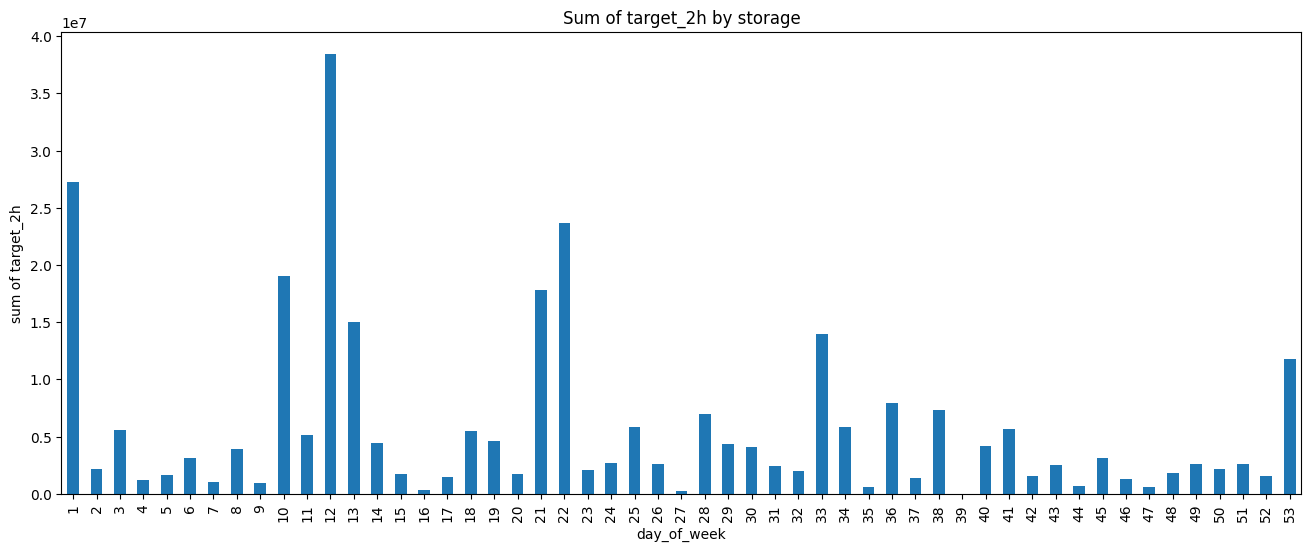

In [34]:
plt.figure(figsize=(16, 6))
grouped_data_sum_sklad = data.groupby('office_from_id')['target_2h'].sum()
grouped_data_sum_sklad.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('sum of target_2h')
plt.title('Sum of target_2h by storage')

Text(0.5, 1.0, 'Median of target_2h by storage')

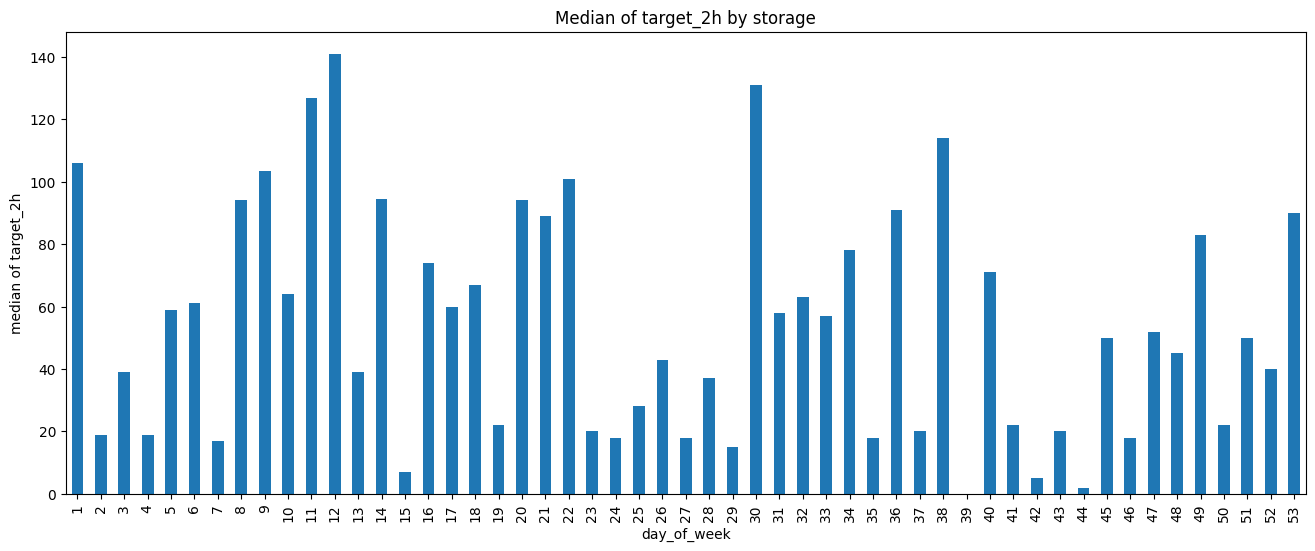

In [35]:
plt.figure(figsize=(16, 6))
grouped_data_median_sklad = data.groupby('office_from_id')['target_2h'].median()
grouped_data_median_sklad.plot(kind='bar')
plt.xlabel('day_of_week')
plt.ylabel('median of target_2h')
plt.title('Median of target_2h by storage')

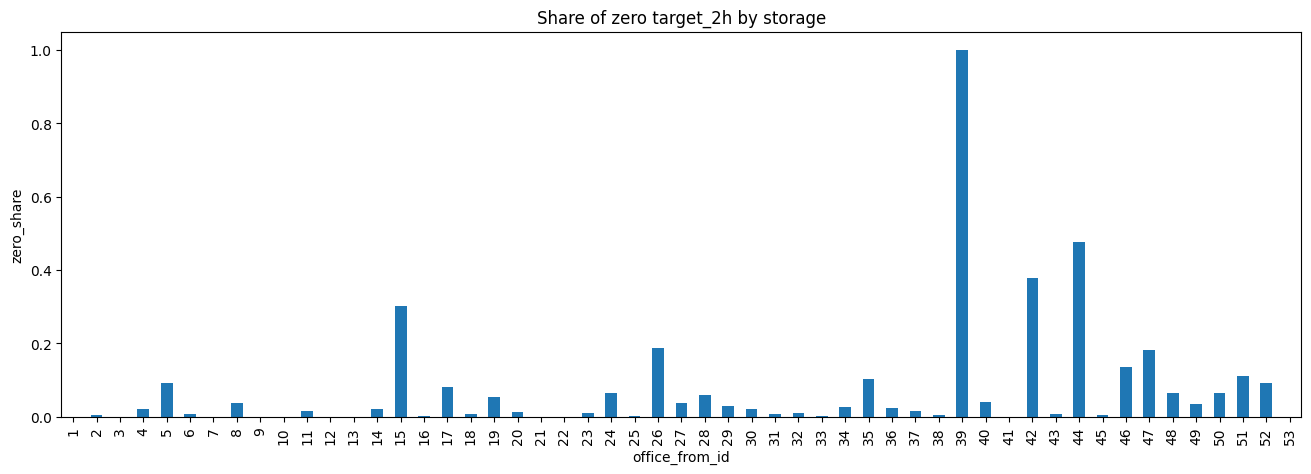

In [36]:
zero_share_by_storage = (data_an['target_2h'] == 0).groupby(data_an['office_from_id']).mean()

zero_share_by_storage.plot(kind='bar', figsize=(16, 5))
plt.xlabel('office_from_id')
plt.ylabel('zero_share')
plt.title('Share of zero target_2h by storage')
plt.show()

In [37]:
data[data['office_from_id'] == 39]

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day_of_week,time_slot
34736,39,243,2025-03-01 00:00:00,0,0,0,0,0,0,0,0,0.0,5,0
34737,39,243,2025-03-01 00:30:00,0,0,0,0,0,0,0,0,0.0,5,1
34738,39,243,2025-03-01 01:00:00,0,0,0,0,0,0,0,0,0.0,5,2
34739,39,243,2025-03-01 01:30:00,0,0,0,0,0,0,0,0,0.0,5,3
34740,39,243,2025-03-01 02:00:00,0,0,0,0,0,0,0,0,0.0,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3968583,39,582,2025-05-30 08:30:00,0,0,0,0,0,0,0,0,0.0,4,17
3968584,39,582,2025-05-30 09:00:00,0,0,0,0,0,0,0,0,0.0,4,18
3968585,39,582,2025-05-30 09:30:00,0,0,0,0,0,0,0,0,0.0,4,19
3968586,39,582,2025-05-30 10:00:00,0,0,0,0,0,0,0,0,0.0,4,20


исключаем склад 39 из обучающей выборки как неактивный в наблюдаемом периоде, поскольку по всем строкам отсутствуют движения в статусах и целевой таргет всегда равен нулю.

In [38]:
idxs = data[data['office_from_id'] == 39].index

In [39]:
data = data.drop(idxs)

ПРОФИЛИ СКЛАДОВ:

In [40]:
# --- копия датасета ---
df = data.copy()
# --- настройки ---
rare_threshold = 0.3   # маршрут считаем редко используемым, если он активен < 5% timestamp

In [41]:
# timestamp в datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# дата и неделя для агрегаций
df['date'] = df['timestamp'].dt.date
df['week'] = df['timestamp'].dt.to_period('W').astype(str)

# флаг активности строки по таргету
df['is_active_target'] = (df['target_2h'] > 0).astype(int)

In [42]:
# =========================
# БЛОК 1. Размер сети
# =========================

# 1. число уникальных маршрутов по складу
n_routes = df.groupby('office_from_id')['route_id'].nunique().rename('n_routes')

# 2. среднее число активных маршрутов на timestamp
# сначала считаем число активных маршрутов в каждый timestamp по складу
active_routes_per_ts = (
    df.loc[df['is_active_target'] == 1]
      .groupby(['office_from_id', 'timestamp'])['route_id']
      .nunique()
      .rename('active_routes_cnt')
      .reset_index()
)

# чтобы timestamp без активных маршрутов тоже учитывались как 0,
# строим полный набор (office_from_id, timestamp)
all_office_ts = df[['office_from_id', 'timestamp']].drop_duplicates()

active_routes_per_ts_full = (
    all_office_ts
    .merge(active_routes_per_ts, on=['office_from_id', 'timestamp'], how='left')
)

active_routes_per_ts_full['active_routes_cnt'] = active_routes_per_ts_full['active_routes_cnt'].fillna(0)

mean_active_routes_per_ts = (
    active_routes_per_ts_full
    .groupby('office_from_id')['active_routes_cnt']
    .mean()
    .rename('mean_active_routes_per_ts')
)

# 3. доля редко используемых маршрутов
# для каждого (склад, маршрут) считаем долю timestamp, где маршрут активен
route_activity = (
    df.groupby(['office_from_id', 'route_id'])
      .agg(
          n_timestamps=('timestamp', 'nunique'),
          active_timestamps=('is_active_target', 'sum')
      )
      .reset_index()
)

route_activity['active_share'] = route_activity['active_timestamps'] / route_activity['n_timestamps']
route_activity['is_rare_route'] = (route_activity['active_share'] < rare_threshold).astype(int)

rare_route_share = (
    route_activity
    .groupby('office_from_id')['is_rare_route']
    .mean()
    .rename('rare_route_share')
)

In [43]:
# =========================
# БЛОК 2. Интенсивность потока
# =========================

flow_stats = (
    df.groupby('office_from_id')
      .agg(
          target_mean=('target_2h', 'mean'),
          target_median=('target_2h', 'median'),
          target_sum_total=('target_2h', 'sum')
      )
)

# средний target_2h по ненулевым строкам
target_mean_nonzero = (
    df.loc[df['target_2h'] > 0]
      .groupby('office_from_id')['target_2h']
      .mean()
      .rename('target_mean_nonzero')
)

# средний дневной суммарный объем
daily_sum = (
    df.groupby(['office_from_id', 'date'])['target_2h']
      .sum()
      .reset_index()
)

avg_daily_target_sum = (
    daily_sum.groupby('office_from_id')['target_2h']
    .mean()
    .rename('avg_daily_target_sum')
)

# средний недельный суммарный объем
weekly_sum = (
    df.groupby(['office_from_id', 'week'])['target_2h']
      .sum()
      .reset_index()
)

avg_weekly_target_sum = (
    weekly_sum.groupby('office_from_id')['target_2h']
    .mean()
    .rename('avg_weekly_target_sum')
)

In [44]:
# =========================
# БЛОК 3. Разреженность и стабильность
# =========================

stability_stats = (
    df.groupby('office_from_id')
      .agg(
          zero_share=('target_2h', lambda x: (x == 0).mean()),
          target_std=('target_2h', 'std'),
          target_p95=('target_2h', lambda x: x.quantile(0.95)),
          target_p99=('target_2h', lambda x: x.quantile(0.99))
      )
)

# коэффициент вариации = std / mean
target_cv = (
    flow_stats['target_mean'].where(flow_stats['target_mean'] != 0, np.nan)
)
target_cv = (stability_stats['target_std'] / target_cv).rename('target_cv')


In [45]:
# =========================
# СБОРКА ИТОГОВОГО ПРОФИЛЯ
# =========================

warehouse_profile = pd.concat(
    [
        n_routes,
        mean_active_routes_per_ts,
        rare_route_share,
        flow_stats,
        target_mean_nonzero,
        avg_daily_target_sum,
        avg_weekly_target_sum,
        stability_stats,
        target_cv
    ],
    axis=1
).reset_index()

# на случай складов, где вообще нет ненулевых target_2h
warehouse_profile['target_mean_nonzero'] = warehouse_profile['target_mean_nonzero'].fillna(0)

# сортировка для удобства
warehouse_profile = warehouse_profile.sort_values('office_from_id').reset_index(drop=True)

warehouse_profile

,office_from_id,n_routes,mean_active_routes_per_ts,rare_route_share,target_mean,target_median,target_sum_total,target_mean_nonzero,avg_daily_target_sum,avg_weekly_target_sum,zero_share,target_std,target_p95,target_p99,target_cv
0,1,54,54.000000,0.000000,116.163707,106.0,27236672.0,116.163707,299304.087912,1.945477e+06,0.000000,55.682741,225.00,279.00,0.479347
1,2,18,17.902119,0.000000,27.290406,19.0,2132909.0,27.439619,23438.560440,1.523506e+05,0.005438,22.817630,72.00,106.00,0.836104
2,3,27,26.991709,0.000000,47.834357,39.0,5607813.0,47.849050,61624.318681,4.005581e+05,0.000307,34.715341,116.00,165.00,0.725741
3,4,7,6.850530,0.000000,38.763506,19.0,1178178.0,39.609279,12947.010989,8.415557e+04,0.021353,64.100256,162.00,340.07,1.653624
4,5,4,3.625749,0.000000,93.300150,59.0,1620437.0,102.930636,17807.000000,1.157455e+05,0.093563,103.870994,331.00,441.00,1.113299
5,6,10,9.925150,0.000000,71.506840,61.0,3104827.0,72.046107,34118.978022,2.217734e+05,0.007485,51.594908,169.00,241.00,0.721538
6,7,13,12.994933,0.000000,18.721203,17.0,1056737.0,18.728502,11612.494505,7.548121e+04,0.000390,10.256800,38.00,49.00,0.547871
7,8,7,6.737448,0.000000,128.494473,94.0,3905461.0,133.501778,42917.153846,2.789615e+05,0.037507,127.855044,405.00,558.00,0.995024
8,9,2,1.998388,0.000000,107.820014,103.5,936309.0,107.906996,10289.109890,6.687921e+04,0.000806,53.824846,202.85,250.00,0.499210
9,10,57,56.995624,0.000000,76.858473,64.0,19022011.0,76.864374,209033.087912,1.358715e+06,0.000077,65.839436,172.00,302.00,0.856632


При пороге 0.05 все нули в признаке rare_route_share, чтобы подобрать порог надо посмотреть на активность маршрутов:

In [46]:
route_profile = (
    df.groupby(['office_from_id', 'route_id'])
    .agg(
        n_timestamps=('timestamp', 'nunique'),
        active_timestamps=('target_2h', lambda x: (x > 0).sum())
    )
    .reset_index()
)

route_profile['active_share'] = (
    route_profile['active_timestamps'] / route_profile['n_timestamps']
)

route_profile.head()

,office_from_id,route_id,n_timestamps,active_timestamps,active_share
0,1,33,4342,4342,1.0
1,1,51,4342,4342,1.0
2,1,52,4342,4342,1.0
3,1,105,4342,4342,1.0
4,1,128,4342,4342,1.0


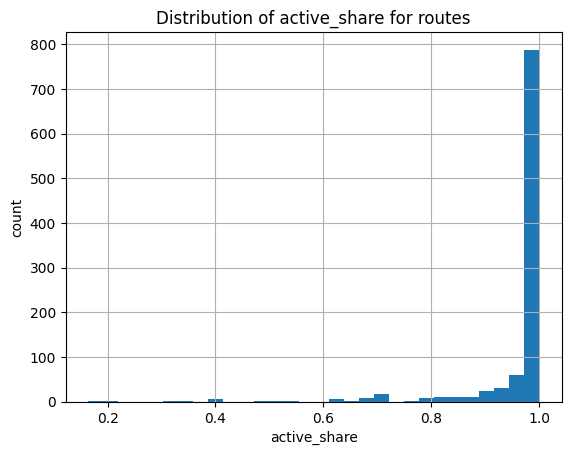

In [47]:
route_profile['active_share'].hist(bins=30)
plt.xlabel('active_share')
plt.ylabel('count')
plt.title('Distribution of active_share for routes')
plt.show()

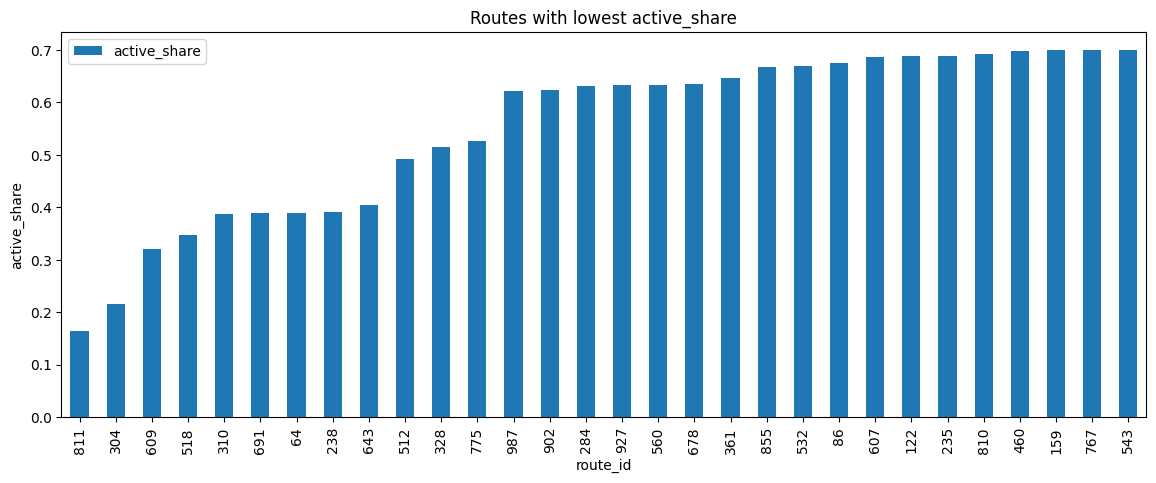

In [48]:
route_profile.sort_values('active_share').head(30).plot(
    x='route_id',
    y='active_share',
    kind='bar',
    figsize=(14, 5)
)
plt.xlabel('route_id')
plt.ylabel('active_share')
plt.title('Routes with lowest active_share')
plt.show()

ставим порог 0.3 - неактивный маршрут

ОБУЧАЕМ БЕЙЗЛАЙН:

In [49]:
data.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day_of_week,time_slot
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0,5,0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0,5,1
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0,5,2
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0,5,3
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0,5,4


In [50]:
data_for_bl = data.copy()
train = data_for_bl[data_for_bl['timestamp'] < '2025-05-01'].copy()
valid = data_for_bl[
    (data_for_bl['timestamp'] >= '2025-05-01') &
    (data_for_bl['timestamp'] < '2025-05-16')
].copy()
test = data_for_bl[data_for_bl['timestamp'] >= '2025-05-16'].copy()

print(train.shape, valid.shape, test.shape)
print(train['timestamp'].min(), train['timestamp'].max())
print(valid['timestamp'].min(), valid['timestamp'].max())
print(test['timestamp'].min(), test['timestamp'].max())

(2881152, 14) (708480, 14) (682896, 14)
2025-03-01 00:00:00 2025-04-30 23:30:00
2025-05-01 00:00:00 2025-05-15 23:30:00
2025-05-16 00:00:00 2025-05-30 10:30:00


In [51]:
features = [
    'office_from_id',
    'route_id',
    'day_of_week',
    'time_slot'
]

target = 'target_2h'

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]
cat_features = ['office_from_id', 'route_id', 'day_of_week', 'time_slot']

In [52]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [53]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

In [55]:
model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# --- предсказания ---
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

# на всякий случай убираем отрицательные предсказания
valid_pred = np.maximum(valid_pred, 0)
test_pred = np.maximum(test_pred, 0)

0:	learn: 46.3281834	test: 47.1155513	best: 47.1155513 (0)	total: 7.92s	remaining: 2h 11m 48s
100:	learn: 23.8262883	test: 26.3678550	best: 26.3678550 (100)	total: 4m 9s	remaining: 37m 1s
200:	learn: 23.3935034	test: 26.1846269	best: 26.1844338 (198)	total: 8m 14s	remaining: 32m 45s
300:	learn: 23.2444307	test: 26.1155781	best: 26.1155781 (300)	total: 12m 31s	remaining: 29m 4s
400:	learn: 23.1612839	test: 26.0729797	best: 26.0728054 (397)	total: 16m 47s	remaining: 25m 4s
500:	learn: 23.0832994	test: 26.0436162	best: 26.0436162 (500)	total: 20m 57s	remaining: 20m 52s
600:	learn: 23.0327398	test: 26.0250436	best: 26.0232548 (580)	total: 24m 56s	remaining: 16m 33s
700:	learn: 22.9996902	test: 26.0196054	best: 26.0174838 (656)	total: 28m 46s	remaining: 12m 16s
800:	learn: 22.9645973	test: 26.0093373	best: 26.0093373 (800)	total: 32m 47s	remaining: 8m 8s
900:	learn: 22.9379912	test: 26.0028102	best: 26.0028102 (900)	total: 36m 49s	remaining: 4m 2s
999:	learn: 22.9176691	test: 25.9994328	bes

In [56]:
model.save_model('bl_final.cbm')

In [ ]:
model_1 = CatBoostRegressor()
model_1.load_model("/content/drive/MyDrive/WB/models/catboost_model_baseline_1.cbm")

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, use_best_model=True, verbose=100)

In [54]:
model = CatBoostRegressor()
model.load_model('bl_final.cbm')

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, use_best_model=True, verbose=100)

In [55]:
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

# на всякий случай убираем отрицательные предсказания
valid_pred = np.maximum(valid_pred, 0)
test_pred = np.maximum(test_pred, 0)

In [56]:
def wape(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  denom = np.sum(np.abs(y_true))
  if denom == 0:
      return np.nan
  return np.sum(np.abs(y_true - y_pred)) / denom

def relative_bias(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  denom = np.sum(np.abs(y_true))
  if denom == 0:
      return np.nan
  return np.sum(y_pred - y_true) / denom

In [57]:
print("VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred))
print("WAPE:", wape(y_valid, valid_pred))
print("Relative Bias:", relative_bias(y_valid, valid_pred))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred)))

print("\nTEST")
print("MAE:", mean_absolute_error(y_test, test_pred))
print("WAPE:", wape(y_test, test_pred))
print("Relative Bias:", relative_bias(y_test, test_pred))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred)))

VALID
MAE: 25.998330140498442
WAPE: 0.3666247905847705
Relative Bias: -0.11385896231919225
|Relative Bias|: 0.11385896231919225

TEST
MAE: 26.75662569692666
WAPE: 0.36433780424827833
Relative Bias: -0.147345261187276
|Relative Bias|: 0.147345261187276


In [58]:
valid_result = valid[['office_from_id', 'target_2h']].copy()
valid_result['pred'] = valid_pred

test_result = test[['office_from_id', 'target_2h']].copy()
test_result['pred'] = test_pred

valid_by_storage = (
    valid_result.groupby('office_from_id')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x)
    }))
    .reset_index()
)

test_by_storage = (
    test_result.groupby('office_from_id')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x)
    }))
    .reset_index()
)

valid_by_storage.sort_values('wape', ascending=False)

/tmp/ipykernel_945/4141710414.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_945/4141710414.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,office_from_id,wape,relative_bias,abs_relative_bias,target_sum,n_rows
42,44,1.097662,-0.099852,0.099852,87765.0,4320.0
40,42,0.998770,-0.998770,0.998770,563139.0,15840.0
28,29,0.958056,0.157816,0.157816,589138.0,23040.0
14,15,0.932358,-0.419340,0.419340,255493.0,10800.0
25,26,0.912396,0.371116,0.371116,300515.0,7200.0
45,47,0.784137,-0.364933,0.364933,112366.0,1440.0
3,4,0.689945,-0.529916,0.529916,204919.0,5040.0
7,8,0.679950,-0.256571,0.256571,605769.0,5040.0
4,5,0.679714,-0.323484,0.323484,261353.0,2880.0
23,24,0.671803,-0.125415,0.125415,463310.0,15120.0


In [59]:
test_by_storage.sort_values('wape', ascending=False)

,office_from_id,wape,relative_bias,abs_relative_bias,target_sum,n_rows
25,26,1.006763,0.610693,0.610693,245453.0,6940.0
40,42,0.999120,-0.999120,0.999120,736463.0,15268.0
42,44,0.960818,-0.074085,0.074085,81996.0,4164.0
14,15,0.887262,-0.485608,0.485608,270264.0,10410.0
28,29,0.808559,0.044642,0.044642,628009.0,22208.0
45,47,0.781636,-0.405907,0.405907,115729.0,1388.0
23,24,0.758905,-0.064722,0.064722,415966.0,14574.0
7,8,0.688201,-0.300541,0.300541,620939.0,4858.0
49,51,0.650258,-0.017951,0.017951,365445.0,4858.0
4,5,0.645248,-0.378219,0.378219,274284.0,2776.0


In [60]:
storage_valid_summary = warehouse_profile.merge(
    valid_by_storage,
    on='office_from_id',
    how='left'
)

storage_valid_summary

,office_from_id,n_routes,mean_active_routes_per_ts,rare_route_share,target_mean,target_median,target_sum_total,target_mean_nonzero,avg_daily_target_sum,avg_weekly_target_sum,zero_share,target_std,target_p95,target_p99,target_cv,wape,relative_bias,abs_relative_bias,target_sum,n_rows
0,1,54,54.000000,0.000000,116.163707,106.0,27236672.0,116.163707,299304.087912,1.945477e+06,0.000000,55.682741,225.00,279.00,0.479347,0.202350,-0.025617,0.025617,4450801.0,38880.0
1,2,18,17.902119,0.000000,27.290406,19.0,2132909.0,27.439619,23438.560440,1.523506e+05,0.005438,22.817630,72.00,106.00,0.836104,0.446795,-0.198207,0.198207,362152.0,12960.0
2,3,27,26.991709,0.000000,47.834357,39.0,5607813.0,47.849050,61624.318681,4.005581e+05,0.000307,34.715341,116.00,165.00,0.725741,0.391659,-0.187455,0.187455,982047.0,19440.0
3,4,7,6.850530,0.000000,38.763506,19.0,1178178.0,39.609279,12947.010989,8.415557e+04,0.021353,64.100256,162.00,340.07,1.653624,0.689945,-0.529916,0.529916,204919.0,5040.0
4,5,4,3.625749,0.000000,93.300150,59.0,1620437.0,102.930636,17807.000000,1.157455e+05,0.093563,103.870994,331.00,441.00,1.113299,0.679714,-0.323484,0.323484,261353.0,2880.0
5,6,10,9.925150,0.000000,71.506840,61.0,3104827.0,72.046107,34118.978022,2.217734e+05,0.007485,51.594908,169.00,241.00,0.721538,0.477097,-0.178755,0.178755,551734.0,7200.0
6,7,13,12.994933,0.000000,18.721203,17.0,1056737.0,18.728502,11612.494505,7.548121e+04,0.000390,10.256800,38.00,49.00,0.547871,0.413675,-0.105884,0.105884,171992.0,9360.0
7,8,7,6.737448,0.000000,128.494473,94.0,3905461.0,133.501778,42917.153846,2.789615e+05,0.037507,127.855044,405.00,558.00,0.995024,0.679950,-0.256571,0.256571,605769.0,5040.0
8,9,2,1.998388,0.000000,107.820014,103.5,936309.0,107.906996,10289.109890,6.687921e+04,0.000806,53.824846,202.85,250.00,0.499210,0.391303,-0.097349,0.097349,161428.0,1440.0
9,10,57,56.995624,0.000000,76.858473,64.0,19022011.0,76.864374,209033.087912,1.358715e+06,0.000077,65.839436,172.00,302.00,0.856632,0.378705,-0.117423,0.117423,3269825.0,41040.0


In [61]:

storage_valid_summary.sort_values('wape', ascending=False).head(15)

,office_from_id,n_routes,mean_active_routes_per_ts,rare_route_share,target_mean,target_median,target_sum_total,target_mean_nonzero,avg_daily_target_sum,avg_weekly_target_sum,zero_share,target_std,target_p95,target_p99,target_cv,wape,relative_bias,abs_relative_bias,target_sum,n_rows
42,44,6,3.138415,0.166667,25.154691,2.0,655330.0,48.090556,7201.428571,46809.285714,0.476931,54.786419,89.0,293.98,2.177980,1.097662,-0.099852,0.099852,87765.0,4320.0
40,42,22,13.679871,0.000000,16.729565,5.0,1598075.0,26.904525,17561.263736,114148.214286,0.378188,23.969440,68.0,102.00,1.432759,0.998770,-0.998770,0.998770,563139.0,15840.0
28,29,32,31.063335,0.000000,31.306577,15.0,4349861.0,32.250576,47800.670330,310704.357143,0.029271,43.228066,119.0,213.57,1.380798,0.958056,0.157816,0.157816,589138.0,23040.0
14,15,15,10.459926,0.066667,26.862874,7.0,1749579.0,38.522558,19226.142857,124969.928571,0.302672,45.820667,97.0,209.00,1.705725,0.932358,-0.419340,0.419340,255493.0,10800.0
25,26,10,8.114694,0.000000,59.853201,43.0,2598826.0,73.759040,28558.527473,185630.428571,0.188531,62.366985,183.0,259.00,1.041999,0.912396,0.371116,0.371116,300515.0,7200.0
45,47,2,1.636112,0.000000,67.216375,52.0,583707.0,82.165963,6414.362637,41693.357143,0.181944,70.912762,206.0,332.34,1.054992,0.784137,-0.364933,0.364933,112366.0,1440.0
3,4,7,6.850530,0.000000,38.763506,19.0,1178178.0,39.609279,12947.010989,84155.571429,0.021353,64.100256,162.0,340.07,1.653624,0.689945,-0.529916,0.529916,204919.0,5040.0
7,8,7,6.737448,0.000000,128.494473,94.0,3905461.0,133.501778,42917.153846,278961.500000,0.037507,127.855044,405.0,558.00,0.995024,0.679950,-0.256571,0.256571,605769.0,5040.0
4,5,4,3.625749,0.000000,93.300150,59.0,1620437.0,102.930636,17807.000000,115745.500000,0.093563,103.870994,331.0,441.00,1.113299,0.679714,-0.323484,0.323484,261353.0,2880.0
23,24,21,19.620912,0.000000,29.567513,18.0,2696025.0,31.645714,29626.648352,192573.214286,0.065671,31.276340,95.0,137.00,1.057794,0.671803,-0.125415,0.125415,463310.0,15120.0


In [62]:
cols_for_corr = [
    'n_routes',
    'mean_active_routes_per_ts',
    'rare_route_share',
    'target_mean',
    'target_median',
    'target_mean_nonzero',
    'avg_daily_target_sum',
    'avg_weekly_target_sum',
    'zero_share',
    'target_std',
    'target_cv',
    'target_p95',
    'target_p99',
    'wape',
    'abs_relative_bias'
]

storage_valid_summary[cols_for_corr].corr()['wape'].sort_values(ascending=False)

,wape
wape,1.000000
target_cv,0.838421
zero_share,0.788488
abs_relative_bias,0.590638
rare_route_share,0.478290
target_std,0.127575
target_p99,0.127087
target_p95,-0.062221
target_mean_nonzero,-0.280076
target_mean,-0.374279


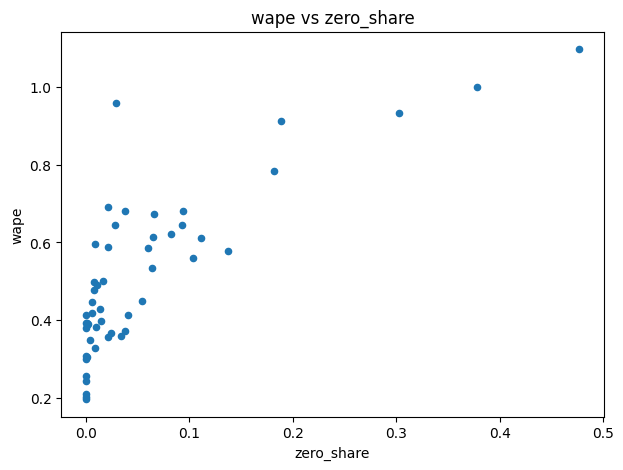

In [63]:
storage_valid_summary.plot.scatter(x='zero_share', y='wape', figsize=(7, 5))
plt.title('wape vs zero_share')
plt.show()

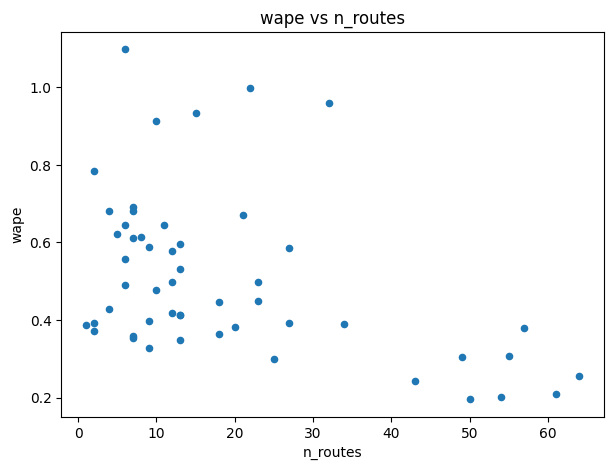

In [64]:
storage_valid_summary.plot.scatter(x='n_routes', y='wape', figsize=(7, 5))
plt.title('wape vs n_routes')
plt.show()

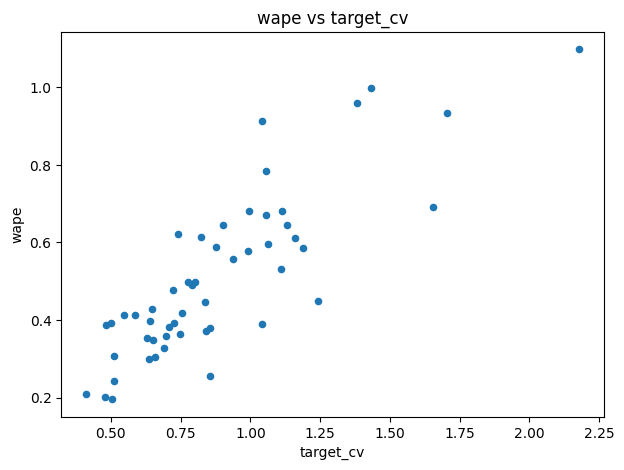

In [65]:

storage_valid_summary.plot.scatter(x='target_cv', y='wape', figsize=(7, 5))
plt.title('wape vs target_cv')
plt.show()

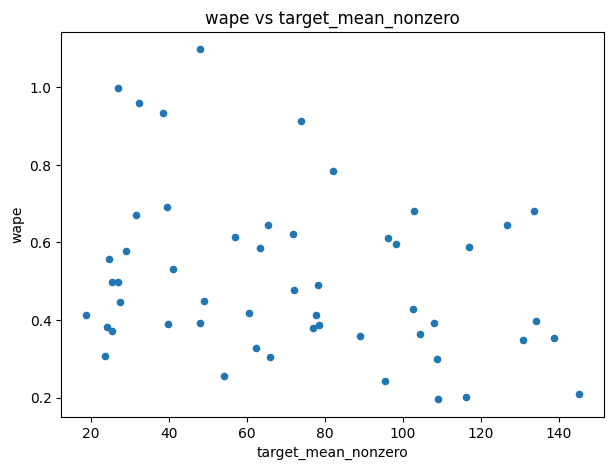

In [66]:
storage_valid_summary.plot.scatter(x='target_mean_nonzero', y='wape', figsize=(7, 5))
plt.title('wape vs target_mean_nonzero')
plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    'zero_share',
    'target_cv',
    'n_routes',
    'mean_active_routes_per_ts',
    'rare_route_share'
]

kmeans_data = storage_valid_summary[['office_from_id'] + cluster_features].copy()

# если есть пропуски, лучше сначала проверить
kmeans_data = kmeans_data.dropna().copy()

X = kmeans_data[cluster_features]

In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_data['cluster'] = kmeans.fit_predict(X_scaled)

In [72]:
storage_valid_summary = storage_valid_summary.merge(
    kmeans_data[['office_from_id', 'cluster']],
    on='office_from_id',
    how='left'
)

storage_valid_summary.head()

,office_from_id,n_routes,mean_active_routes_per_ts,rare_route_share,target_mean,target_median,target_sum_total,target_mean_nonzero,avg_daily_target_sum,avg_weekly_target_sum,...,target_std,target_p95,target_p99,target_cv,wape,relative_bias,abs_relative_bias,target_sum,n_rows,cluster
0,1,54,54.000000,0.0,116.163707,106.0,27236672.0,116.163707,299304.087912,1.945477e+06,...,55.682741,225.0,279.00,0.479347,0.202350,-0.025617,0.025617,4450801.0,38880.0,1
1,2,18,17.902119,0.0,27.290406,19.0,2132909.0,27.439619,23438.560440,1.523506e+05,...,22.817630,72.0,106.00,0.836104,0.446795,-0.198207,0.198207,362152.0,12960.0,0
2,3,27,26.991709,0.0,47.834357,39.0,5607813.0,47.849050,61624.318681,4.005581e+05,...,34.715341,116.0,165.00,0.725741,0.391659,-0.187455,0.187455,982047.0,19440.0,0
3,4,7,6.850530,0.0,38.763506,19.0,1178178.0,39.609279,12947.010989,8.415557e+04,...,64.100256,162.0,340.07,1.653624,0.689945,-0.529916,0.529916,204919.0,5040.0,3
4,5,4,3.625749,0.0,93.300150,59.0,1620437.0,102.930636,17807.000000,1.157455e+05,...,103.870994,331.0,441.00,1.113299,0.679714,-0.323484,0.323484,261353.0,2880.0,3


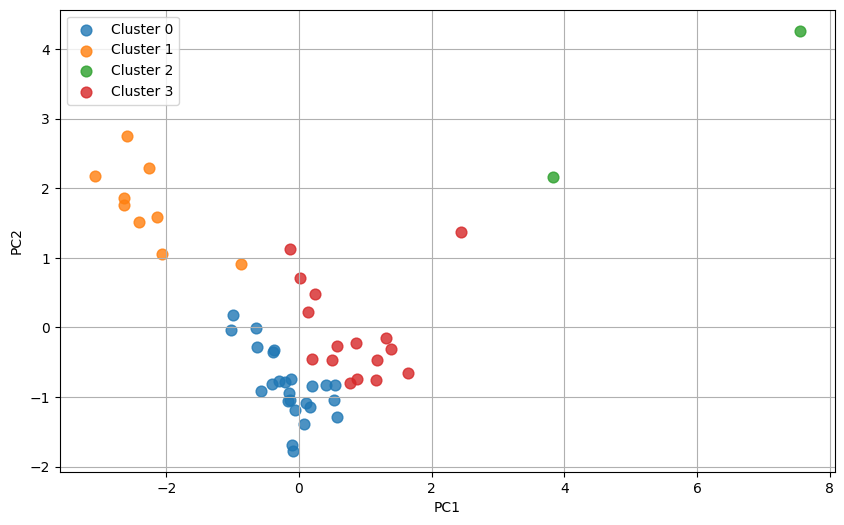

In [78]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA до 2 компонент
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = kmeans_data.copy()
plot_df['pc1'] = X_pca[:, 0]
plot_df['pc2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
for cl in sorted(plot_df['cluster'].unique()):
    tmp = plot_df[plot_df['cluster'] == cl]
    plt.scatter(tmp['pc1'], tmp['pc2'], label=f'Cluster {cl}', s=60, alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

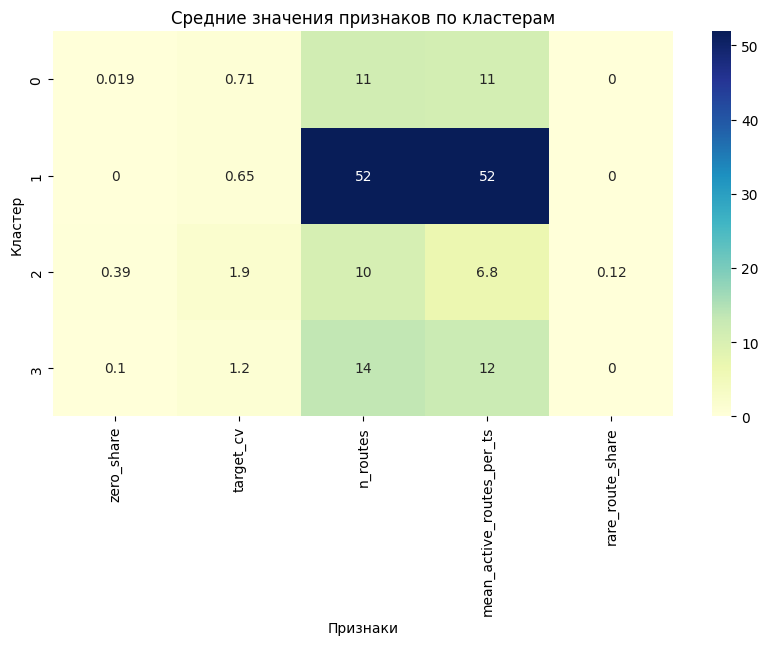

In [77]:
import seaborn as sns
cluster_profile = (
    kmeans_data.groupby('cluster')[cluster_features]
    .mean()
    .round(3)
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu')
plt.title('Средние значения признаков по кластерам')
plt.xlabel('Признаки')
plt.ylabel('Кластер')
plt.show()

In [81]:
storage_valid_summary['cluster'].value_counts().sort_index()

,count
cluster,
0,25
1,9
2,2
3,16


In [82]:
cluster_sizes = storage_valid_summary['cluster'].value_counts().sort_index().rename('cluster_size')

cluster_summary = (
    storage_valid_summary
    .groupby('cluster')[cluster_features]
    .mean()
    .round(3)
)

cluster_summary = cluster_summary.merge(
    cluster_sizes,
    left_index=True,
    right_index=True,
    how='left'
)

cluster_summary

,zero_share,target_cv,n_routes,mean_active_routes_per_ts,rare_route_share,cluster_size
cluster,,,,,,
0,0.019,0.714,11.200,11.040,0.000,25
1,0.000,0.648,51.889,51.875,0.000,9
2,0.390,1.942,10.500,6.799,0.117,2
3,0.101,1.154,13.500,12.180,0.000,16


In [83]:
storage_valid_summary.groupby('cluster')[['wape', 'abs_relative_bias']].mean().round(3)

,wape,abs_relative_bias
cluster,,
0,0.438,0.135
1,0.276,0.077
2,1.015,0.260
3,0.681,0.305


In [84]:
data_with_cluster = data.merge(
    storage_valid_summary[['office_from_id', 'cluster']].drop_duplicates(),
    on='office_from_id',
    how='left'
)

In [85]:
data_with_cluster['cluster'].isna().sum()

np.int64(0)

In [86]:
data_for_bl = data_with_cluster.copy()
train = data_for_bl[data_for_bl['timestamp'] < '2025-05-01'].copy()
valid = data_for_bl[
    (data_for_bl['timestamp'] >= '2025-05-01') &
    (data_for_bl['timestamp'] < '2025-05-16')
].copy()
test = data_for_bl[data_for_bl['timestamp'] >= '2025-05-16'].copy()

print(train.shape, valid.shape, test.shape)
print(train['timestamp'].min(), train['timestamp'].max())
print(valid['timestamp'].min(), valid['timestamp'].max())
print(test['timestamp'].min(), test['timestamp'].max())

(2881152, 15) (708480, 15) (682896, 15)
2025-03-01 00:00:00 2025-04-30 23:30:00
2025-05-01 00:00:00 2025-05-15 23:30:00
2025-05-16 00:00:00 2025-05-30 10:30:00


In [87]:
data_for_bl.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day_of_week,time_slot,cluster
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0,5,0,3
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0,5,1,3
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0,5,2,3
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0,5,3,3
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0,5,4,3


In [88]:
features = [
    'office_from_id',
    'route_id',
    'time_slot',
    'cluster'
]

target = 'target_2h'

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]
cat_features = ['office_from_id', 'route_id', 'time_slot', 'cluster']

In [ ]:
model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=900,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# --- предсказания ---
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

# на всякий случай убираем отрицательные предсказания
valid_pred = np.maximum(valid_pred, 0)
test_pred = np.maximum(test_pred, 0)

0:	learn: 46.3279761	test: 47.1139647	best: 47.1139647 (0)	total: 5.24s	remaining: 1h 18m 30s


KeyboardInterrupt: 

In [89]:
model_2 = CatBoostRegressor()
model_2.load_model("/content/drive/MyDrive/WB/models/catboost_model_baseline_2.cbm")

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=900, learning_rate=0.05, loss_function='MAE', random_seed=42, use_best_model=True, verbose=100)

In [90]:
valid_pred = model_2.predict(X_valid)
test_pred = model_2.predict(X_test)

# на всякий случай убираем отрицательные предсказания
valid_pred = np.maximum(valid_pred, 0)
test_pred = np.maximum(test_pred, 0)

In [91]:
print("VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred))
print("WAPE:", wape(y_valid, valid_pred))
print("Relative Bias:", relative_bias(y_valid, valid_pred))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred)))

print("\nTEST")
print("MAE:", mean_absolute_error(y_test, test_pred))
print("WAPE:", wape(y_test, test_pred))
print("Relative Bias:", relative_bias(y_test, test_pred))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred)))

VALID
MAE: 26.342187893182174
WAPE: 0.3714738241914422
Relative Bias: -0.12249253448336767
|Relative Bias|: 0.12249253448336767

TEST
MAE: 27.155804783942248
WAPE: 0.3697733189395721
Relative Bias: -0.1540418843672363
|Relative Bias|: 0.1540418843672363


СТРОИМ ПРОФИЛИ ПО МАРШРУТАМ И СКЛАДАМ (УРЕЗАННЫЙ), ЧТОБЫ ДОБАВИТЬ ИХ К ДАННЫМ

In [ ]:
route_profile_train = (
    train.groupby('route_id')
    .agg(
        route_target_mean_train=('target_2h', 'mean'),
        route_target_median_train=('target_2h', 'median'),
        route_zero_share_train=('target_2h', lambda x: (x == 0).mean()),
        route_target_mean_nonzero_train=('target_2h', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        route_target_std_train=('target_2h', 'std'),
        route_target_p95_train=('target_2h', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

route_profile_train['route_target_std_train'] = route_profile_train['route_target_std_train'].fillna(0)
route_profile_train

,route_id,route_target_mean_train,route_target_median_train,route_zero_share_train,route_target_mean_nonzero_train,route_target_std_train,route_target_p95_train
0,0,46.060109,17.0,0.189208,56.808762,52.130232,139.65
1,1,127.771516,127.0,0.000000,127.771516,34.146263,183.65
2,2,7.120219,7.0,0.074454,7.692989,4.419561,15.00
3,3,90.637978,90.0,0.010929,91.639503,39.863108,158.00
4,4,26.938866,24.0,0.005464,27.086882,15.972132,56.00
...,...,...,...,...,...,...,...
979,995,192.402322,192.0,0.000000,192.402322,46.853376,272.00
980,996,12.500342,12.0,0.075820,13.525868,9.871536,25.00
981,997,15.992145,15.0,0.095970,17.689838,10.678819,34.00
982,998,83.059768,81.0,0.000000,83.059768,23.007185,123.00


In [ ]:
storage_profile_train = (
    train.groupby('office_from_id')
    .agg(
        storage_target_mean_train=('target_2h', 'mean'),
        storage_target_median_train=('target_2h', 'median'),
        storage_zero_share_train=('target_2h', lambda x: (x == 0).mean()),
        storage_target_std_train=('target_2h', 'std'),
        storage_target_p95_train=('target_2h', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

storage_profile_train['storage_target_std_train'] = storage_profile_train['storage_target_std_train'].fillna(0)
storage_profile_train

,office_from_id,storage_target_mean_train,storage_target_median_train,storage_zero_share_train,storage_target_std_train,storage_target_p95_train
0,1,116.447107,106.0,0.000000,55.526592,226.00
1,2,26.110827,18.0,0.007267,22.558735,70.00
2,3,46.208688,37.0,0.000228,33.570094,113.00
3,4,39.119975,17.0,0.025859,65.482447,170.00
4,5,92.622951,56.0,0.096141,105.853560,336.00
5,6,70.473053,61.0,0.010485,49.612881,161.00
6,7,18.230270,16.0,0.000447,9.782605,37.00
7,8,130.696380,98.0,0.047961,128.601194,404.00
8,9,105.588286,101.0,0.001025,54.162179,202.00
9,10,74.714888,64.0,0.000030,52.681271,168.00


In [ ]:
# число уникальных маршрутов по складу на train
n_routes_train = (
    train.groupby('office_from_id')['route_id']
    .nunique()
    .rename('n_routes_train')
    .reset_index()
)

# среднее число активных маршрутов на timestamp
tmp_active = (
    train.loc[train['target_2h'] > 0]
    .groupby(['office_from_id', 'timestamp'])['route_id']
    .nunique()
    .rename('active_routes_cnt')
    .reset_index()
)

all_office_ts_train = train[['office_from_id', 'timestamp']].drop_duplicates()

tmp_active_full = all_office_ts_train.merge(
    tmp_active,
    on=['office_from_id', 'timestamp'],
    how='left'
)
tmp_active_full['active_routes_cnt'] = tmp_active_full['active_routes_cnt'].fillna(0)

mean_active_routes_per_ts_train = (
    tmp_active_full.groupby('office_from_id')['active_routes_cnt']
    .mean()
    .rename('mean_active_routes_per_ts_train')
    .reset_index()
)

storage_profile_train = (
    storage_profile_train
    .merge(n_routes_train, on='office_from_id', how='left')
    .merge(mean_active_routes_per_ts_train, on='office_from_id', how='left')
)

storage_profile_train['storage_target_cv_train'] = (
    storage_profile_train['storage_target_std_train'] /
    storage_profile_train['storage_target_mean_train'].replace(0, np.nan)
)

storage_profile_train['storage_target_cv_train'] = storage_profile_train['storage_target_cv_train'].fillna(0)

storage_profile_train

,office_from_id,storage_target_mean_train,storage_target_median_train,storage_zero_share_train,storage_target_std_train,storage_target_p95_train,n_routes_train,mean_active_routes_per_ts_train,storage_target_cv_train
0,1,116.447107,106.0,0.000000,55.526592,226.00,54,54.000000,0.476840
1,2,26.110827,18.0,0.007267,22.558735,70.00,18,17.869194,0.863961
2,3,46.208688,37.0,0.000228,33.570094,113.00,27,26.993852,0.726489
3,4,39.119975,17.0,0.025859,65.482447,170.00,7,6.818989,1.673888
4,5,92.622951,56.0,0.096141,105.853560,336.00,4,3.615437,1.142844
5,6,70.473053,61.0,0.010485,49.612881,161.00,10,9.895150,0.703998
6,7,18.230270,16.0,0.000447,9.782605,37.00,13,12.994194,0.536613
7,8,130.696380,98.0,0.047961,128.601194,404.00,7,6.664276,0.983969
8,9,105.588286,101.0,0.001025,54.162179,202.00,2,1.997951,0.512956
9,10,74.714888,64.0,0.000030,52.681271,168.00,57,56.998292,0.705097


In [ ]:
train_ext = (
    train
    .merge(route_profile_train, on='route_id', how='left')
    .merge(storage_profile_train, on='office_from_id', how='left')
)

valid_ext = (
    valid
    .merge(route_profile_train, on='route_id', how='left')
    .merge(storage_profile_train, on='office_from_id', how='left')
)

test_ext = (
    test
    .merge(route_profile_train, on='route_id', how='left')
    .merge(storage_profile_train, on='office_from_id', how='left')
)

In [ ]:
train_ext

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,...,route_target_std_train,route_target_p95_train,storage_target_mean_train,storage_target_median_train,storage_zero_share_train,storage_target_std_train,storage_target_p95_train,n_routes_train,mean_active_routes_per_ts_train,storage_target_cv_train
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,...,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,7,6.818989,1.673888
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,...,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,7,6.818989,1.673888
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,...,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,7,6.818989,1.673888
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,...,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,7,6.818989,1.673888
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,...,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,7,6.818989,1.673888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881147,53,526,2025-04-30 21:30:00,0,137,0,408,386,137,594,...,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,25,24.998975,0.642222
2881148,53,526,2025-04-30 22:00:00,0,125,0,442,529,256,9941,...,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,25,24.998975,0.642222
2881149,53,526,2025-04-30 22:30:00,0,111,0,622,311,676,0,...,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,25,24.998975,0.642222
2881150,53,526,2025-04-30 23:00:00,0,127,0,809,549,432,0,...,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,25,24.998975,0.642222


In [ ]:
for df in [train_ext, valid_ext, test_ext]:
  df['route_target_mean_train'] = df['route_target_mean_train'].fillna(train['target_2h'].mean())
  df['route_target_median_train'] = df['route_target_median_train'].fillna(train['target_2h'].median())
  df['route_zero_share_train'] = df['route_zero_share_train'].fillna((train['target_2h'] == 0).mean())
  df['route_target_mean_nonzero_train'] = df['route_target_mean_nonzero_train'].fillna(
      train.loc[train['target_2h'] > 0, 'target_2h'].mean()
  )
  df['route_target_std_train'] = df['route_target_std_train'].fillna(0)
  df['route_target_p95_train'] = df['route_target_p95_train'].fillna(train['target_2h'].quantile(0.95))

  df['storage_target_mean_train'] = df['storage_target_mean_train'].fillna(train['target_2h'].mean())
  df['storage_target_median_train'] = df['storage_target_median_train'].fillna(train['target_2h'].median())
  df['storage_zero_share_train'] = df['storage_zero_share_train'].fillna((train['target_2h'] == 0).mean())
  df['storage_target_std_train'] = df['storage_target_std_train'].fillna(0)
  df['storage_target_p95_train'] = df['storage_target_p95_train'].fillna(train['target_2h'].quantile(0.95))
  df['n_routes_train'] = df['n_routes_train'].fillna(train.groupby('office_from_id')['route_id'].nunique().mean())
  df['mean_active_routes_per_ts_train'] = df['mean_active_routes_per_ts_train'].fillna(
      tmp_active_full.groupby('office_from_id')['active_routes_cnt'].mean().mean()
  )
  df['storage_target_cv_train'] = df['storage_target_cv_train'].fillna(0)

In [ ]:
features = [
    'office_from_id',
    'route_id',
    'time_slot',
    'cluster',

    'route_target_mean_train',
    'route_target_median_train',
    'route_zero_share_train',
    'route_target_mean_nonzero_train',
    'route_target_std_train',
    'route_target_p95_train',

    'storage_target_mean_train',
    'storage_target_median_train',
    'storage_zero_share_train',
    'storage_target_std_train',
    'storage_target_p95_train',
    'storage_target_cv_train',
    'n_routes_train',
    'mean_active_routes_per_ts_train'
]

target = 'target_2h'

cat_features = ['office_from_id', 'route_id', 'time_slot', 'cluster']

In [ ]:
X_train = train_ext[features]
y_train = train_ext[target]

X_valid = valid_ext[features]
y_valid = valid_ext[target]

X_test = test_ext[features]
y_test = test_ext[target]

In [ ]:
X_train

,office_from_id,route_id,time_slot,cluster,route_target_mean_train,route_target_median_train,route_zero_share_train,route_target_mean_nonzero_train,route_target_std_train,route_target_p95_train,storage_target_mean_train,storage_target_median_train,storage_zero_share_train,storage_target_std_train,storage_target_p95_train,storage_target_cv_train,n_routes_train,mean_active_routes_per_ts_train
0,4,29,0,3,78.720287,46.0,0.001366,78.827975,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,1.673888,7,6.818989
1,4,29,1,3,78.720287,46.0,0.001366,78.827975,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,1.673888,7,6.818989
2,4,29,2,3,78.720287,46.0,0.001366,78.827975,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,1.673888,7,6.818989
3,4,29,3,3,78.720287,46.0,0.001366,78.827975,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,1.673888,7,6.818989
4,4,29,4,3,78.720287,46.0,0.001366,78.827975,85.122809,308.65,39.119975,17.0,0.025859,65.482447,170.0,1.673888,7,6.818989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881147,53,526,43,0,84.238388,82.0,0.000000,84.238388,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,0.642222,25,24.998975
2881148,53,526,44,0,84.238388,82.0,0.000000,84.238388,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,0.642222,25,24.998975
2881149,53,526,45,0,84.238388,82.0,0.000000,84.238388,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,0.642222,25,24.998975
2881150,53,526,46,0,84.238388,82.0,0.000000,84.238388,23.603848,125.00,107.948770,89.0,0.000041,69.327035,239.0,0.642222,25,24.998975


In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=1000,
    learning_rate=0.08,
    depth=8,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 45.1894084	test: 46.0381211	best: 46.0381211 (0)	total: 7.98s	remaining: 2h 12m 50s
100:	learn: 21.3192543	test: 24.2994924	best: 24.2994924 (100)	total: 8m 30s	remaining: 1h 15m 46s
200:	learn: 21.2838698	test: 24.2722827	best: 24.2722827 (200)	total: 14m 48s	remaining: 58m 52s
300:	learn: 21.2462321	test: 24.2490703	best: 24.2490161 (297)	total: 21m 11s	remaining: 49m 12s
400:	learn: 21.2373981	test: 24.2447057	best: 24.2446379 (399)	total: 27m 3s	remaining: 40m 25s
500:	learn: 21.2183986	test: 24.2430927	best: 24.2422912 (417)	total: 33m 27s	remaining: 33m 19s
600:	learn: 21.2138716	test: 24.2385499	best: 24.2382951 (521)	total: 39m 28s	remaining: 26m 12s
700:	learn: 21.2068636	test: 24.2353461	best: 24.2353364 (693)	total: 45m 46s	remaining: 19m 31s
800:	learn: 21.2058081	test: 24.2344744	best: 24.2344643 (789)	total: 51m 13s	remaining: 12m 43s
900:	learn: 21.2040270	test: 24.2331555	best: 24.2331555 (900)	total: 56m 34s	remaining: 6m 12s
999:	learn: 21.2026048	test: 24.2

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.08, loss_function='MAE', random_seed=42, verbose=100)

In [ ]:
model_3 = CatBoostRegressor()
model_3.load_model("/content/drive/MyDrive/WB/models/catboost_model_baseline_3.cbm")

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, use_best_model=True, verbose=100)

In [ ]:
valid_pred = model_3.predict(X_valid)
test_pred = model_3.predict(X_test)

valid_pred = np.maximum(valid_pred, 0)
test_pred = np.maximum(test_pred, 0)

print("VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred))
print("WAPE:", wape(y_valid, valid_pred))
print("Relative Bias:", relative_bias(y_valid, valid_pred))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred)))

print("\nTEST")
print("MAE:", mean_absolute_error(y_test, test_pred))
print("WAPE:", wape(y_test, test_pred))
print("Relative Bias:", relative_bias(y_test, test_pred))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred)))

VALID
MAE: 24.23126136563397
WAPE: 0.3417058355583322
Relative Bias: -0.09635372779683037
|Relative Bias|: 0.09635372779683037

TEST
MAE: 24.921496025931337
WAPE: 0.33934933513357607
Relative Bias: -0.12883359872415656
|Relative Bias|: 0.12883359872415656


In [ ]:
valid_result = valid_ext[['office_from_id', 'cluster', 'target_2h']].copy()
valid_result['pred'] = valid_pred

test_result = test_ext[['office_from_id', 'cluster', 'target_2h']].copy()
test_result['pred'] = test_pred

In [ ]:
valid_by_cluster = (
    valid_result.groupby('cluster')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x),
        'n_storages': x['office_from_id'].nunique()
    }))
    .reset_index()
)

valid_by_cluster

/tmp/ipykernel_8060/3937254282.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,cluster,wape,relative_bias,abs_relative_bias,target_sum,n_rows,n_storages
0,0,0.401684,-0.120967,0.120967,14263147.0,201600.0,25.0
1,1,0.216844,-0.041991,0.041991,27860174.0,336240.0,9.0
2,2,0.920156,-0.572648,0.572648,343258.0,15120.0,2.0
3,3,0.653614,-0.224995,0.224995,7773605.0,155520.0,16.0


In [ ]:
test_by_cluster = (
    test_result.groupby('cluster')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x),
        'n_storages': x['office_from_id'].nunique()
    }))
    .reset_index()
)

test_by_cluster

/tmp/ipykernel_8060/3196080801.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,cluster,wape,relative_bias,abs_relative_bias,target_sum,n_rows,n_storages
0,0,0.395973,-0.156530,0.156530,14311403.0,194320.0,25.0
1,1,0.214579,-0.076586,0.076586,27807392.0,324098.0,9.0
2,2,0.863346,-0.600427,0.600427,352260.0,14574.0,2.0
3,3,0.661554,-0.244766,0.244766,7680185.0,149904.0,16.0


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# копии
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()
X_test_lgb = X_test.copy()

# категориальные признаки переведем в category
cat_features_lgb = ['office_from_id', 'route_id', 'time_slot', 'cluster']

for col in cat_features_lgb:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_valid_lgb[col] = X_valid_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_model = LGBMRegressor(
    objective='mae',
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=96,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric='l1'
)

valid_pred_lgb = lgb_model.predict(X_valid_lgb)
test_pred_lgb = lgb_model.predict(X_test_lgb)

valid_pred_lgb = np.maximum(valid_pred_lgb, 0)
test_pred_lgb = np.maximum(test_pred_lgb, 0)

print("LIGHTGBM VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred_lgb))
print("WAPE:", wape(y_valid, valid_pred_lgb))
print("Relative Bias:", relative_bias(y_valid, valid_pred_lgb))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred_lgb)))

print("\nLIGHTGBM TEST")
print("MAE:", mean_absolute_error(y_test, test_pred_lgb))
print("WAPE:", wape(y_test, test_pred_lgb))
print("Relative Bias:", relative_bias(y_test, test_pred_lgb))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred_lgb)))

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()
X_test_xgb = X_test.copy()

xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_valid_xgb, y_valid)],
    verbose=100
)

valid_pred_xgb = xgb_model.predict(X_valid_xgb)
test_pred_xgb = xgb_model.predict(X_test_xgb)

valid_pred_xgb = np.maximum(valid_pred_xgb, 0)
test_pred_xgb = np.maximum(test_pred_xgb, 0)

print("XGBOOST VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred_xgb))
print("WAPE:", wape(y_valid, valid_pred_xgb))
print("Relative Bias:", relative_bias(y_valid, valid_pred_xgb))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred_xgb)))

print("\nXGBOOST TEST")
print("MAE:", mean_absolute_error(y_test, test_pred_xgb))
print("WAPE:", wape(y_test, test_pred_xgb))
print("Relative Bias:", relative_bias(y_test, test_pred_xgb))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred_xgb)))

[0]	validation_0-mae:46.96792
[100]	validation_0-mae:24.09530
[200]	validation_0-mae:24.05153
[300]	validation_0-mae:24.04340
[400]	validation_0-mae:24.03595
[500]	validation_0-mae:24.02521
[600]	validation_0-mae:24.01895
[700]	validation_0-mae:24.01096
[800]	validation_0-mae:24.00245
[900]	validation_0-mae:23.99951
[999]	validation_0-mae:23.99889
XGBOOST VALID
MAE: 23.998881453454636
WAPE: 0.33842884676026547
Relative Bias: -0.09312690879277803
|Relative Bias|: 0.09312690879277803

XGBOOST TEST
MAE: 24.771042285249692
WAPE: 0.33730064685195965
Relative Bias: -0.12563559899546817
|Relative Bias|: 0.12563559899546817


In [ ]:
def assign_segment(cluster):
    if cluster in [0, 1]:
        return 'stable'
    elif cluster in [2, 3]:
        return 'sparse_volatile'
    return 'unknown'

for df in [train_ext, valid_ext, test_ext]:
    df['segment'] = df['cluster'].apply(assign_segment)

In [ ]:
print(train_ext['segment'].value_counts())
print(valid_ext['segment'].value_counts())
print(test_ext['segment'].value_counts())

segment
stable             2187216
sparse_volatile     693936
Name: count, dtype: int64
segment
stable             537840
sparse_volatile    170640
Name: count, dtype: int64
segment
stable             518418
sparse_volatile    164478
Name: count, dtype: int64


In [ ]:
features = [
    'office_from_id',
    'route_id',
    'time_slot',
    'cluster',

    'route_target_mean_train',
    'route_zero_share_train',
    'route_target_std_train',

    'storage_target_mean_train',
    'storage_zero_share_train',
    'storage_target_cv_train',

    'n_routes_train',
    'mean_active_routes_per_ts_train'
]

target = 'target_2h'
cat_features = ['office_from_id', 'route_id', 'time_slot', 'cluster']

In [ ]:
train_stable = train_ext[train_ext['segment'] == 'stable'].copy()
valid_stable = valid_ext[valid_ext['segment'] == 'stable'].copy()
test_stable = test_ext[test_ext['segment'] == 'stable'].copy()

train_sparse = train_ext[train_ext['segment'] == 'sparse_volatile'].copy()
valid_sparse = valid_ext[valid_ext['segment'] == 'sparse_volatile'].copy()
test_sparse = test_ext[test_ext['segment'] == 'sparse_volatile'].copy()

In [ ]:
from catboost import CatBoostRegressor
import numpy as np

model_stable = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

model_stable.fit(
    train_stable[features],
    train_stable[target],
    cat_features=cat_features,
    eval_set=(valid_stable[features], valid_stable[target]),
    use_best_model=True
)

0:	learn: 46.0512179	test: 47.9456711	best: 47.9456711 (0)	total: 6.66s	remaining: 1h 50m 55s
100:	learn: 19.5223039	test: 22.0200669	best: 22.0200669 (100)	total: 5m 54s	remaining: 52m 33s
200:	learn: 19.2070581	test: 21.8170282	best: 21.8170282 (200)	total: 11m 15s	remaining: 44m 47s
300:	learn: 19.0978252	test: 21.7617335	best: 21.7617335 (300)	total: 16m 30s	remaining: 38m 20s
400:	learn: 19.0335093	test: 21.7366317	best: 21.7361729 (398)	total: 22m 7s	remaining: 33m 3s
500:	learn: 18.9910801	test: 21.7218861	best: 21.7217716 (498)	total: 27m 49s	remaining: 27m 42s
600:	learn: 18.9576725	test: 21.7118193	best: 21.7118193 (600)	total: 33m 26s	remaining: 22m 11s
700:	learn: 18.9322540	test: 21.7038983	best: 21.7038983 (700)	total: 38m 53s	remaining: 16m 35s
800:	learn: 18.9120912	test: 21.6978094	best: 21.6978094 (800)	total: 44m 25s	remaining: 11m 2s
900:	learn: 18.8944950	test: 21.6938992	best: 21.6938265 (899)	total: 49m 39s	remaining: 5m 27s
999:	learn: 18.8803768	test: 21.689692

CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [ ]:
model_stable.save_model("catboost_model_baseline_stable.cbm")

In [ ]:
model_sparse = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    random_seed=42,
    verbose=100
)

model_sparse.fit(
    train_sparse[features],
    train_sparse[target],
    cat_features=cat_features,
    eval_set=(valid_sparse[features], valid_sparse[target]),
    use_best_model=True
)

0:	learn: 38.3703755	test: 37.4877570	best: 37.4877570 (0)	total: 1.77s	remaining: 29m 24s
100:	learn: 27.0263321	test: 31.6642671	best: 31.4422606 (18)	total: 1m 36s	remaining: 14m 15s


KeyboardInterrupt: 

In [ ]:
model_sparse.save_model("catboost_model_baseline_sparse.cbm")

In [ ]:
valid_stable_pred = np.maximum(model_stable.predict(valid_stable[features]), 0)
valid_sparse_pred = np.maximum(model_sparse.predict(valid_sparse[features]), 0)

test_stable_pred = np.maximum(model_stable.predict(test_stable[features]), 0)
test_sparse_pred = np.maximum(model_sparse.predict(test_sparse[features]), 0)

In [ ]:
valid_pred_segmented = pd.Series(index=valid_ext.index, dtype=float)
test_pred_segmented = pd.Series(index=test_ext.index, dtype=float)

valid_pred_segmented.loc[valid_stable.index] = valid_stable_pred
valid_pred_segmented.loc[valid_sparse.index] = valid_sparse_pred

test_pred_segmented.loc[test_stable.index] = test_stable_pred
test_pred_segmented.loc[test_sparse.index] = test_sparse_pred

In [ ]:
print(valid_pred_segmented.isna().sum())
print(test_pred_segmented.isna().sum())

0
0


In [ ]:
from sklearn.metrics import mean_absolute_error

print("SEGMENTED VALID")
print("MAE:", mean_absolute_error(y_valid, valid_pred_segmented.loc[y_valid.index]))
print("WAPE:", wape(y_valid, valid_pred_segmented.loc[y_valid.index]))
print("Relative Bias:", relative_bias(y_valid, valid_pred_segmented.loc[y_valid.index]))
print("|Relative Bias|:", abs(relative_bias(y_valid, valid_pred_segmented.loc[y_valid.index])))

print("\nSEGMENTED TEST")
print("MAE:", mean_absolute_error(y_test, test_pred_segmented.loc[y_test.index]))
print("WAPE:", wape(y_test, test_pred_segmented.loc[y_test.index]))
print("Relative Bias:", relative_bias(y_test, test_pred_segmented.loc[y_test.index]))
print("|Relative Bias|:", abs(relative_bias(y_test, test_pred_segmented.loc[y_test.index])))

SEGMENTED VALID
MAE: 24.03048889935754
WAPE: 0.3388745705114621
Relative Bias: -0.10440504875901972
|Relative Bias|: 0.10440504875901972

SEGMENTED TEST
MAE: 24.67010335786184
WAPE: 0.335926188518378
Relative Bias: -0.13651016259306145
|Relative Bias|: 0.13651016259306145


In [ ]:
valid_segment_result = valid_ext[['segment', 'target_2h']].copy()
valid_segment_result['pred'] = valid_pred_segmented

test_segment_result = test_ext[['segment', 'target_2h']].copy()
test_segment_result['pred'] = test_pred_segmented

valid_by_segment = (
    valid_segment_result.groupby('segment')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x)
    }))
    .reset_index()
)

test_by_segment = (
    test_segment_result.groupby('segment')
    .apply(lambda x: pd.Series({
        'wape': wape(x['target_2h'], x['pred']),
        'relative_bias': relative_bias(x['target_2h'], x['pred']),
        'abs_relative_bias': abs(relative_bias(x['target_2h'], x['pred'])),
        'target_sum': x['target_2h'].sum(),
        'n_rows': len(x)
    }))
    .reset_index()
)

valid_by_segment, test_by_segment

/tmp/ipykernel_8060/545971285.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_8060/545971285.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


(           segment      wape  relative_bias  abs_relative_bias  target_sum  \
 0  sparse_volatile  0.660306      -0.289046           0.289046   8116863.0   
 1           stable  0.276937      -0.068826           0.068826  42123321.0   
 
      n_rows  
 0  170640.0  
 1  537840.0  ,
            segment      wape  relative_bias  abs_relative_bias  target_sum  \
 0  sparse_volatile  0.657345      -0.308009           0.308009   8032445.0   
 1           stable  0.274629      -0.103804           0.103804  42118795.0   
 
      n_rows  
 0  164478.0  
 1  518418.0  )